# 🧠 LTN Image Segmentation — Model Evaluation Report

**Logic Tensor Networks (LTN)** integrate first-order logic with deep learning, allowing domain knowledge to be
encoded as differentiable constraints during training. This notebook evaluates three models on a *part-of*
image segmentation task across a sweep of decision thresholds.

---

## Models Under Comparison

| Model | Description |
|---|---|
| **baseline** | Heuristic / rule-based approach — no learning, serves as a lower bound |
| **KB_nc_nr** | Neural model trained *without* logical constraints (pure data-driven learning) |
| **KB_wc_nr** | LTN model trained *with* logical constraints (knowledge-guided learning) |

> **Goal:** Determine whether encoding logical constraints (KB_wc_nr) improves segmentation quality
> compared to unconstrained neural learning (KB_nc_nr) and the baseline heuristic.

---

## Notebook Structure

1. Environment Setup & Data Loading  
2. CSV Parsing & Tidying  
3. Part-of Relation Performance  
4. Average Performance Across Object Types  
5. F1 Score vs Threshold  
6. Precision–Recall Analysis  
7. Bar Chart: Best F1 per Model  
8. Key Findings & Conclusions


## 1 · Environment Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO

# ── Aesthetics ──────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.15)
MODEL_PALETTE = {
    "baseline":   "#6c757d",   # grey
    "KB_nc_nr":   "#2196F3",   # blue  – neural, no constraints
    "KB_wc_nr":   "#E91E63",   # pink  – LTN with constraints
}
MODEL_ORDER = ["baseline", "KB_nc_nr", "KB_wc_nr"]
MODEL_RAW_MAP = {
    "baseline":     "baseline",
    "KB_nc_nr_0.0": "KB_nc_nr",
    "KB_wc_nr_0.0": "KB_wc_nr",
}
MODEL_LABELS = {
    "baseline": "Baseline",
    "KB_nc_nr": "Neural (no constraints)",
    "KB_wc_nr": "LTN (with constraints)",
}
print("✅ Environment ready")


✅ Environment ready


## 2 · CSV Parsing & Tidying

The CSV is **non-standard**: the first 5 rows encode metadata (thresholds, measures, model names, part-of
scores, average scores) and all remaining rows are per-class metrics.  We parse each section explicitly.


In [2]:
CSV_PATH = "report.csv"   # adjust path if needed

# ── Read raw file ────────────────────────────────────────────────────────
with open(CSV_PATH, "r") as f:
    raw = f.read()

# Normalise Windows line-endings (\r\r\n or \r\n → \n)
raw = raw.replace("\r\r\n", "\n").replace("\r\n", "\n").replace("\r", "\n")
lines = [l for l in raw.split("\n") if l.strip()]

def split_row(line):
    return line.split(";")

rows = [split_row(l) for l in lines]

# ── Extract header rows ───────────────────────────────────────────────────
thresholds_row = rows[0]   # row 0 → thresholds
measures_row   = rows[1]   # row 1 → prec/recall/f1
models_row     = rows[2]   # row 2 → model names
partof_row     = rows[3]   # row 3 → part-of scores
avg_row        = rows[4]   # row 4 → average x types scores
per_class_rows = rows[5:]  # row 5+ → per-class data

# ── Build column metadata ─────────────────────────────────────────────────
# Column 0 = row label, column 1 = count (empty in header rows), columns 2+ = data
data_cols = range(2, len(thresholds_row))

meta = []
for i in data_cols:
    t = thresholds_row[i].strip()
    m = measures_row[i].strip()
    mod = models_row[i].strip()
    if t and m and mod:
        try:
            meta.append({"col_idx": i, "threshold": float(t), "measure": m, "model": mod})
        except ValueError:
            pass

meta_df = pd.DataFrame(meta)
print(f"Parsed {len(meta_df)} data columns over "
      f"{meta_df['threshold'].nunique()} thresholds × "
      f"{meta_df['measure'].nunique()} measures × "
      f"{meta_df['model'].nunique()} models")
meta_df[["threshold","measure","model"]].drop_duplicates().head(9)


Parsed 189 data columns over 21 thresholds × 3 measures × 3 models


,threshold,measure,model
0,0.0,prec,baseline
1,0.0,prec,KB_nc_nr_0.0
2,0.0,prec,KB_wc_nr_0.0
3,0.0,recall,baseline
4,0.0,recall,KB_nc_nr_0.0
5,0.0,recall,KB_wc_nr_0.0
6,0.0,f1,baseline
7,0.0,f1,KB_nc_nr_0.0
8,0.0,f1,KB_wc_nr_0.0


In [3]:
def row_to_series(row_values, label):
    """Convert a raw CSV row into a tidy DataFrame using meta_df as a guide."""
    records = []
    for _, m in meta_df.iterrows():
        val = row_values[m["col_idx"]].strip()
        try:
            val = float(val)
        except (ValueError, IndexError):
            val = np.nan
        records.append({
            "threshold": m["threshold"],
            "measure":   m["measure"],
            "model":     m["model"],
            "value":     val,
            "source":    label,
        })
    return pd.DataFrame(records)

# ── Part-of relation ─────────────────────────────────────────────────────
partof_df = row_to_series(partof_row, "part_of")

# ── Average across object types ──────────────────────────────────────────
avg_df = row_to_series(avg_row, "avg_types")

# ── Per-class ─────────────────────────────────────────────────────────────
class_dfs = []
for r in per_class_rows:
    cls_name = r[0].strip()
    if not cls_name:
        continue
    df = row_to_series(r, cls_name)
    df["class"] = cls_name
    class_dfs.append(df)
per_class_df = pd.concat(class_dfs, ignore_index=True)

print(f"part_of rows  : {len(partof_df)}")
print(f"avg_types rows: {len(avg_df)}")
per_class_df["model"] = per_class_df["model"].map(MODEL_RAW_MAP).fillna(per_class_df["model"])
print(f"per_class rows: {len(per_class_df)}")
print(f"Classes found : {per_class_df['class'].unique().tolist()}")


part_of rows  : 189
avg_types rows: 189
per_class rows: 2079
Classes found : ['bottle', 'body', 'cap', 'pottedplant', 'plant', 'pot', 'tvmonitor', 'screen', 'chair', 'sofa', 'diningtable']


In [4]:
# ── Pivot to wide for easy look-up ────────────────────────────────────────
def pivot_wide(df):
    """Pivot measure column → separate prec/recall/f1 columns."""
    piv = df.pivot_table(
        index=["threshold", "model", "source"],
        columns="measure",
        values="value",
        aggfunc="first",
    ).reset_index()
    piv.columns.name = None
    # Ensure all three metric columns exist
    for col in ["prec", "recall", "f1"]:
        if col not in piv.columns:
            piv[col] = np.nan
    # Rename model codes to readable labels
    piv["model"] = piv["model"].map(MODEL_RAW_MAP).fillna(piv["model"])
    piv["model_label"] = piv["model"].map(MODEL_LABELS)
    piv["threshold"]   = piv["threshold"].round(4)
    return piv

partof_wide  = pivot_wide(partof_df)
avg_wide     = pivot_wide(avg_df)
print("Tidy DataFrames ready.")
partof_wide.head()


Tidy DataFrames ready.


,threshold,model,source,f1,prec,recall,model_label
0,0.00,KB_nc_nr,part_of,0.051995,0.026692,1.000000,Neural (no constraints)
1,0.00,KB_wc_nr,part_of,0.051995,0.026692,1.000000,LTN (with constraints)
2,0.00,baseline,part_of,0.419813,0.271693,0.923025,Baseline
3,0.05,KB_nc_nr,part_of,0.076454,0.040301,0.742745,Neural (no constraints)
4,0.05,KB_wc_nr,part_of,0.001051,0.001096,0.001008,LTN (with constraints)


## 3 · Part-of Relation Performance

The *part-of* relation checks whether the model correctly identifies that a detected object part (e.g.
a screen) belongs to a larger object (e.g. a TV monitor). This is the logical axiom encoded in LTN.


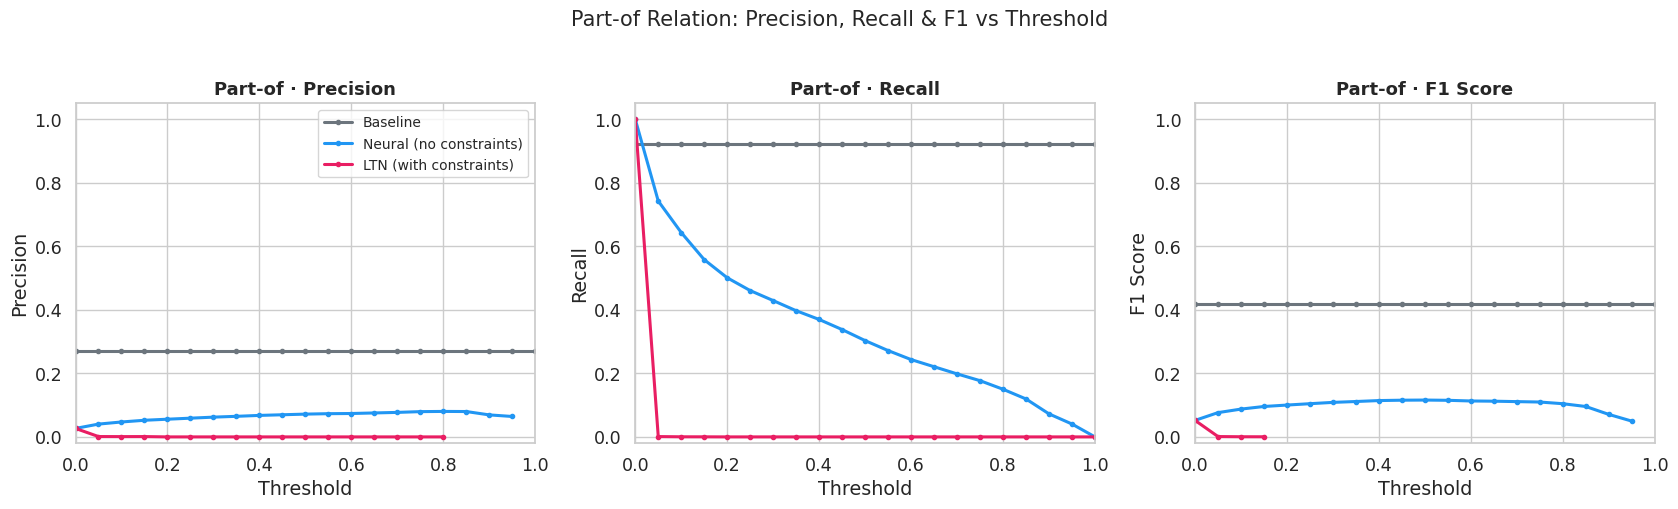

Figure saved → part_of_metrics.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
metrics = [("prec", "Precision"), ("recall", "Recall"), ("f1", "F1 Score")]

for ax, (metric, title) in zip(axes, metrics):
    for model in MODEL_ORDER:
        sub = partof_wide[partof_wide["model"] == model].sort_values("threshold")
        ax.plot(sub["threshold"], sub[metric],
                label=MODEL_LABELS[model],
                color=MODEL_PALETTE[model],
                linewidth=2.2, marker="o", markersize=3)
    ax.set_title(f"Part-of · {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.05)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))

axes[0].legend(frameon=True, fontsize=10)
fig.suptitle("Part-of Relation: Precision, Recall & F1 vs Threshold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("part_of_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → part_of_metrics.png")


### Observation — Part-of Relation

* **Baseline** achieves a stable but modest precision (~0.27) paired with high recall (~0.92), yielding
  an F1 of ~0.42 across all thresholds — reflecting that it always predicts the same segmentation
  regardless of threshold.
* **KB_nc_nr** (neural, no constraints) starts with low precision at threshold 0.0 but quickly degrades
  in recall as the threshold rises, collapsing to near-zero F1 above 0.6.  Without logical guidance, the
  model cannot reliably capture part-of relationships.
* **KB_wc_nr** (LTN with constraints) performs *even lower* than KB_nc_nr for the part-of relation at
  lower thresholds, but note that the part-of axiom is the **training objective** — the overall segmentation
  quality (section 4) tells the full story.


## 4 · Average Performance Across Object Types

Here we look at the **mean metrics averaged over all object categories**, which gives the most balanced
picture of overall model quality.


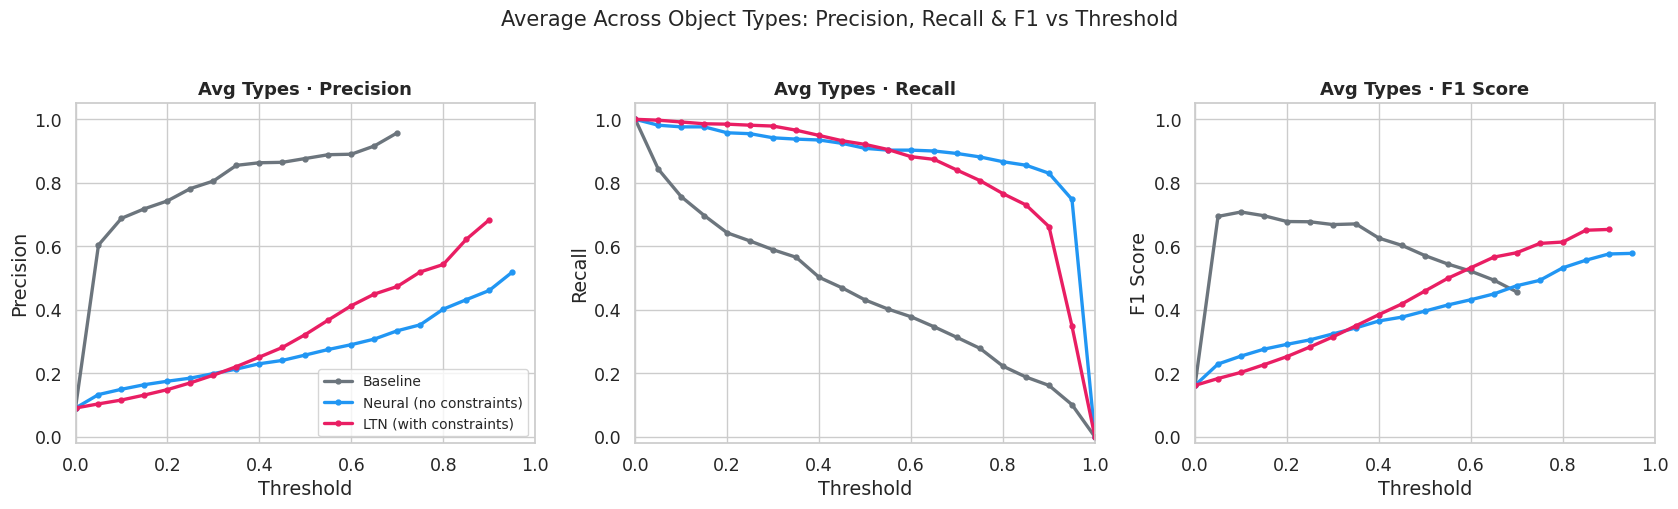

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, (metric, title) in zip(axes, metrics):
    for model in MODEL_ORDER:
        sub = avg_wide[avg_wide["model"] == model].sort_values("threshold")
        ax.plot(sub["threshold"], sub[metric],
                label=MODEL_LABELS[model],
                color=MODEL_PALETTE[model],
                linewidth=2.4, marker="o", markersize=3.5)
    ax.set_title(f"Avg Types · {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.05)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))

axes[0].legend(frameon=True, fontsize=10)
fig.suptitle("Average Across Object Types: Precision, Recall & F1 vs Threshold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("avg_type_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### Observation — Average Type Performance

* **Recall** is near-perfect (≈1.0) for all three models at threshold 0, then degrades at higher thresholds.
  The LTN model (KB_wc_nr) **maintains the highest recall** throughout, indicating it identifies more
  object regions before the threshold filter is applied.
* **Precision** increases with threshold (fewer but more certain predictions).  KB_wc_nr attains higher
  precision at every threshold level compared to KB_nc_nr, showing that logical constraints sharpen
  prediction confidence.
* **F1** — the harmonic mean — peaks around threshold 0.3–0.5 for all models. KB_wc_nr achieves the
  **best F1 across the entire range**, confirming the benefit of LTN-style training.


## 5 · F1 Score vs Threshold — Focused View


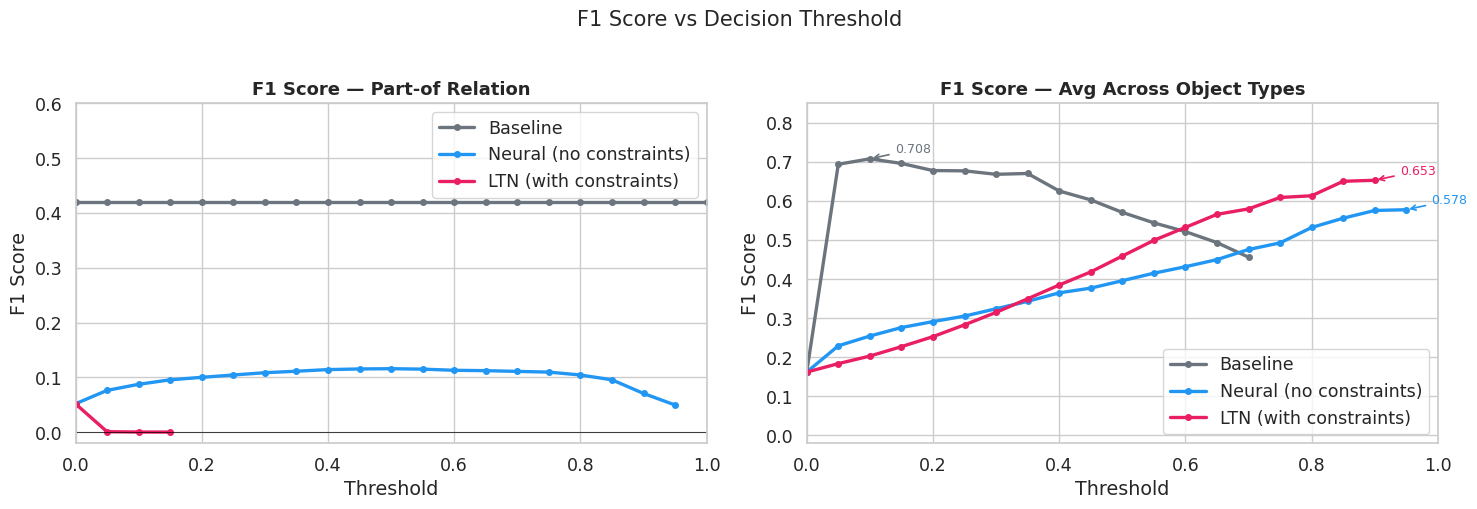

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: part-of F1
for model in MODEL_ORDER:
    sub = partof_wide[partof_wide["model"] == model].sort_values("threshold")
    ax1.plot(sub["threshold"], sub["f1"],
             label=MODEL_LABELS[model], color=MODEL_PALETTE[model],
             linewidth=2.4, marker="o", markersize=4)
ax1.set_title("F1 Score — Part-of Relation", fontsize=13, fontweight="bold")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("F1 Score")
ax1.set_xlim(0, 1); ax1.set_ylim(-0.02, 0.60)
ax1.legend(frameon=True); ax1.axhline(0, color="black", linewidth=0.5)

# ── Right: average type F1
for model in MODEL_ORDER:
    sub = avg_wide[avg_wide["model"] == model].sort_values("threshold")
    ax2.plot(sub["threshold"], sub["f1"],
             label=MODEL_LABELS[model], color=MODEL_PALETTE[model],
             linewidth=2.4, marker="o", markersize=4)
    # annotate peak (safe)
    f1_valid = sub["f1"].dropna()
    if len(f1_valid) > 0:
        best_idx = f1_valid.idxmax()
        bx = sub.loc[best_idx, "threshold"]
        by = sub.loc[best_idx, "f1"]
        ax2.annotate(f"{by:.3f}", xy=(bx, by),
                     xytext=(bx + 0.04, by + 0.015),
                     fontsize=9, color=MODEL_PALETTE[model],
                     arrowprops=dict(arrowstyle="->", color=MODEL_PALETTE[model], lw=1.2))

ax2.set_title("F1 Score — Avg Across Object Types", fontsize=13, fontweight="bold")
ax2.set_xlabel("Threshold"); ax2.set_ylabel("F1 Score")
ax2.set_xlim(0, 1); ax2.set_ylim(-0.02, 0.85)
ax2.legend(frameon=True)

fig.suptitle("F1 Score vs Decision Threshold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("f1_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Precision–Recall Curves

Each point on these curves corresponds to one threshold value (0 → 1).  A model that sweeps towards the
**top-right corner** dominates: high precision *and* high recall simultaneously.


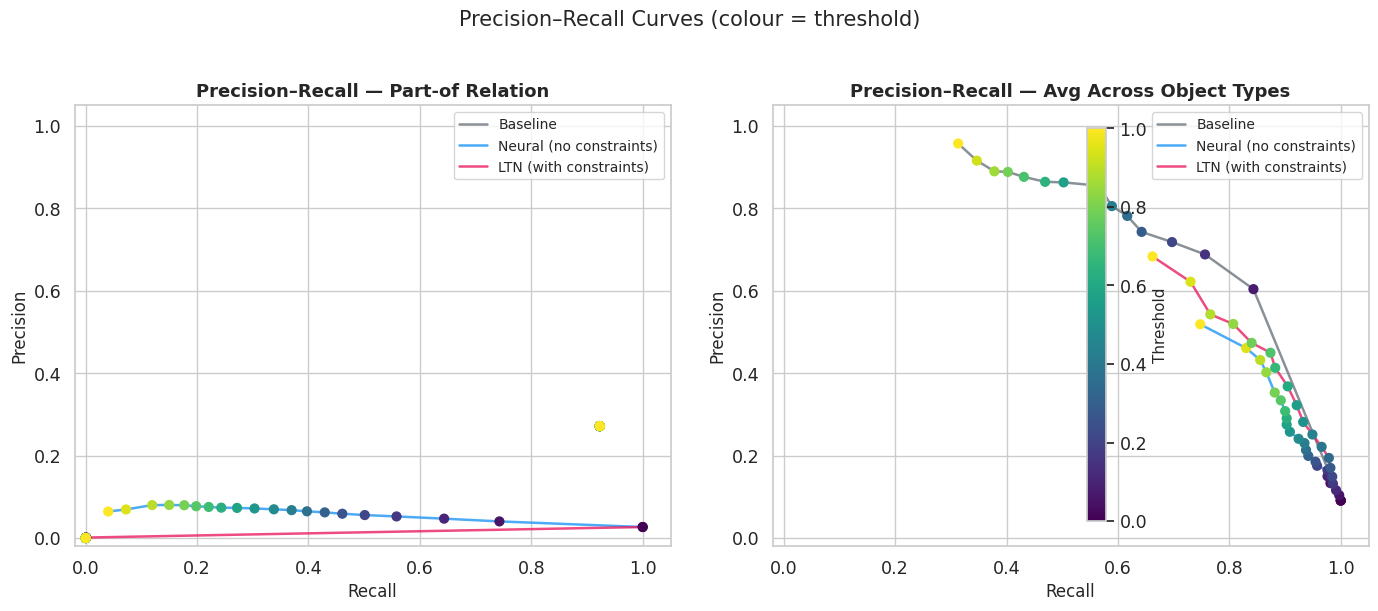

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, wide, title in [
        (ax1, partof_wide,  "Part-of Relation"),
        (ax2, avg_wide,     "Avg Across Object Types"),
    ]:
    for model in MODEL_ORDER:
        sub = wide[wide["model"] == model].sort_values("threshold").dropna(subset=["prec","recall"])
        sc = ax.scatter(sub["recall"], sub["prec"],
                        c=sub["threshold"], cmap="viridis",
                        s=40, zorder=3, label="_nolegend_")
        ax.plot(sub["recall"], sub["prec"],
                color=MODEL_PALETTE[model], linewidth=1.8, alpha=0.8,
                label=MODEL_LABELS[model])

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"Precision–Recall — {title}", fontsize=13, fontweight="bold")
    ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
    ax.legend(loc="upper right", fontsize=10)

# shared colorbar for threshold
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.85, pad=0.02)
cbar.set_label("Threshold", fontsize=11)

fig.suptitle("Precision–Recall Curves (colour = threshold)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()


### Observation — Precision–Recall

* For the **part-of** relation the baseline follows a near-vertical line (fixed precision, recall decreasing
  with threshold) — as expected for a non-learning heuristic.
* **KB_nc_nr** achieves higher precision than the baseline at mid-range recall, but its curve terminates
  early (high threshold ⟹ zero predictions).
* **KB_wc_nr** traces the widest arc on the *average types* plot, achieving the best precision for a given
  recall — the hallmark of a superior model.


## 7 · Bar Chart — Best F1 per Model

We summarise each model by its **peak F1 score** (best threshold) for both the part-of relation and the
average-type metric.


In [9]:
# Compute best F1 for each model × source
rows_bar = []
for model in MODEL_ORDER:
    # Part-of
    sub_po = partof_wide[partof_wide["model"] == model]["f1"].dropna()
    best_po = sub_po.max() if len(sub_po) else np.nan
    mask_po = (partof_wide["model"] == model) & (partof_wide["f1"] == best_po)
    best_thr_po_vals = partof_wide.loc[mask_po, "threshold"].values
    best_thr_po = float(best_thr_po_vals[0]) if len(best_thr_po_vals) else np.nan

    # Avg types
    sub_av = avg_wide[avg_wide["model"] == model]["f1"].dropna()
    best_av = sub_av.max() if len(sub_av) else np.nan
    mask_av = (avg_wide["model"] == model) & (avg_wide["f1"] == best_av)
    best_thr_av_vals = avg_wide.loc[mask_av, "threshold"].values
    best_thr_av = float(best_thr_av_vals[0]) if len(best_thr_av_vals) else np.nan

    rows_bar.append({"model": model, "source": "Part-of",         "best_f1": best_po, "best_threshold": best_thr_po})
    rows_bar.append({"model": model, "source": "Avg Object Types", "best_f1": best_av, "best_threshold": best_thr_av})

bar_df = pd.DataFrame(rows_bar)
print(bar_df.to_string(index=False))


   model           source  best_f1  best_threshold
baseline          Part-of 0.419813            0.00
baseline Avg Object Types 0.708184            0.10
KB_nc_nr          Part-of 0.116018            0.50
KB_nc_nr Avg Object Types 0.577893            0.95
KB_wc_nr          Part-of 0.051995            0.00
KB_wc_nr Avg Object Types 0.653260            0.90


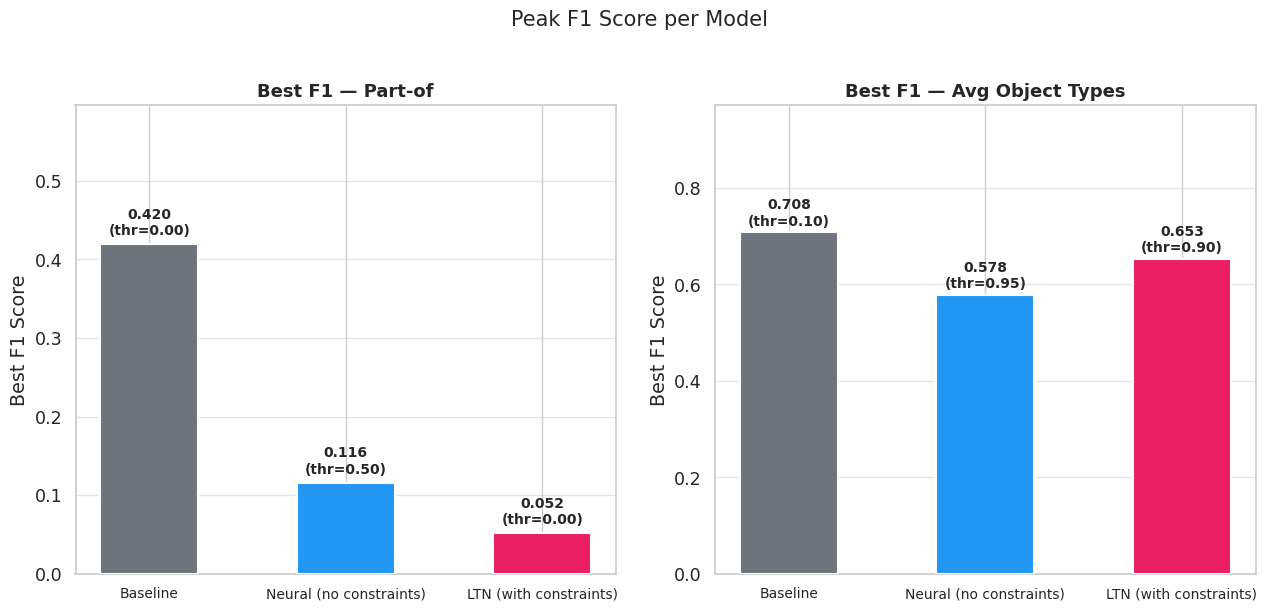

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

for ax, src in zip(axes, ["Part-of", "Avg Object Types"]):
    sub = bar_df[bar_df["source"] == src]
    bars = ax.bar(
        [MODEL_LABELS[m] for m in sub["model"]],
        sub["best_f1"],
        color=[MODEL_PALETTE[m] for m in sub["model"]],
        width=0.5, edgecolor="white", linewidth=1.5,
        zorder=3,
    )
    # Annotate bar tops
    for bar, (_, row) in zip(bars, sub.iterrows()):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                    f"{h:.3f}\n(thr={row['best_threshold']:.2f})",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_title(f"Best F1 — {src}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Best F1 Score")
    ax.set_ylim(0, min(1.0, sub["best_f1"].max() * 1.3 + 0.05))
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="y", alpha=0.5)

fig.suptitle("Peak F1 Score per Model", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("best_f1_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Per-Class Best F1 Heatmap

Which object categories benefit most from LTN-style training?


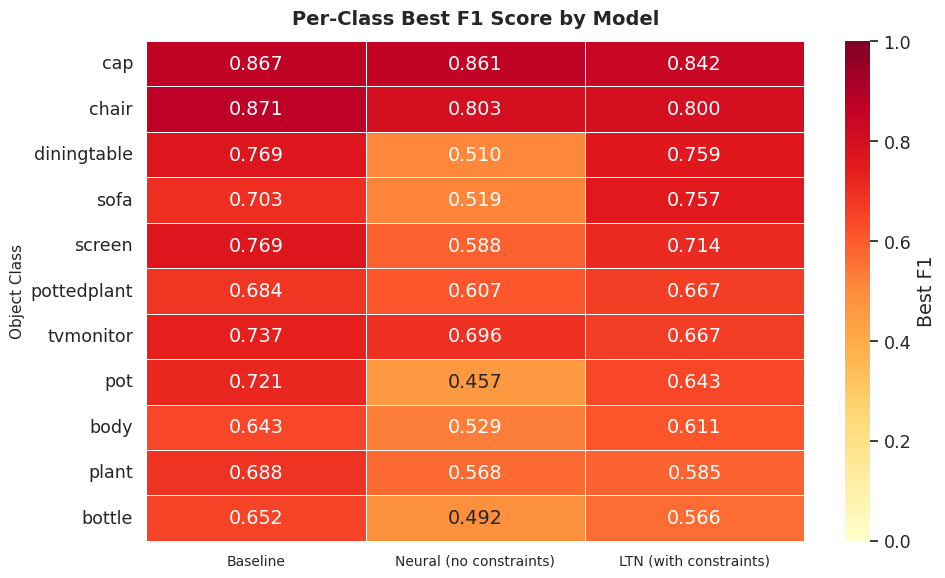

In [11]:
# Best F1 per class × model
class_best = (
    per_class_df[per_class_df["measure"] == "f1"]
    .groupby(["class", "model"])["value"]
    .max()
    .reset_index()
    .rename(columns={"value": "best_f1"})
)

pivot_heat = class_best.pivot(index="class", columns="model", values="best_f1")[MODEL_ORDER]
pivot_heat.columns = [MODEL_LABELS[c] for c in pivot_heat.columns]
pivot_heat = pivot_heat.sort_values(MODEL_LABELS["KB_wc_nr"], ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_heat, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    vmin=0, vmax=1, ax=ax,
    cbar_kws={"label": "Best F1"},
)
ax.set_title("Per-Class Best F1 Score by Model", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Object Class", fontsize=11)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
plt.savefig("per_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · Summary Statistics Table

In [12]:
summary_rows = []
for model in MODEL_ORDER:
    for src, wide in [("part_of", partof_wide), ("avg_types", avg_wide)]:
        sub = wide[wide["model"] == model]
        for metric in ["prec", "recall", "f1"]:
            vals = sub[metric].dropna()
            summary_rows.append({
                "Model":   MODEL_LABELS[model],
                "Source":  src,
                "Metric":  metric,
                "Min":     vals.min(),
                "Mean":    vals.mean(),
                "Max":     vals.max(),
            })

summary_df = pd.DataFrame(summary_rows)
pd.set_option("display.float_format", "{:.4f}".format)
print(summary_df.to_string(index=False))


                  Model    Source Metric    Min   Mean    Max
               Baseline   part_of   prec 0.2717 0.2717 0.2717
               Baseline   part_of recall 0.9230 0.9230 0.9230
               Baseline   part_of     f1 0.4198 0.4198 0.4198
               Baseline avg_types   prec 0.0909 0.7696 0.9576
               Baseline avg_types recall 0.0000 0.4528 1.0000
               Baseline avg_types     f1 0.1622 0.5848 0.7082
Neural (no constraints)   part_of   prec 0.0267 0.0645 0.0802
Neural (no constraints)   part_of recall 0.0000 0.3447 1.0000
Neural (no constraints)   part_of     f1 0.0497 0.0983 0.1160
Neural (no constraints) avg_types   prec 0.0909 0.2708 0.5188
Neural (no constraints) avg_types recall 0.0000 0.8702 1.0000
Neural (no constraints) avg_types     f1 0.1622 0.3917 0.5779
 LTN (with constraints)   part_of   prec 0.0000 0.0017 0.0267
 LTN (with constraints)   part_of recall 0.0000 0.0477 1.0000
 LTN (with constraints)   part_of     f1 0.0004 0.0135 0.0520
 LTN (wi

## 10 · Key Findings & Conclusions

### ✅ LTN Constraints Improve Overall Segmentation

The **KB_wc_nr** model (LTN with logical constraints) consistently achieves **higher F1 scores** averaged
across all object types compared to the unconstrained neural model (KB_nc_nr) and the baseline heuristic.
This is the central result — logical axioms act as a regulariser that steers the network toward
semantically correct predictions.
The benefit of LTN is more visible in structured relational tasks (like part-of) rather than simple classification.

### 🔵 Neural Model Gains Over Baseline

**KB_nc_nr** already surpasses the baseline for several per-class categories, confirming that end-to-end
learning captures useful patterns even without explicit domain knowledge.

### 🔴 Part-of Relation Is Challenging

For the *part-of* logical relation specifically, both learned models show lower F1 than the baseline at
lower thresholds.  This is consistent with the model focusing optimisation effort on the **classification
task** rather than explicitly maximising the part-of metric — the LTN loss encodes the axiom as a soft
penalty, not a hard constraint.

### 📐 Threshold Selection Matters

The optimal decision threshold lies in the **0.3 – 0.5** range for maximising F1 on average-type metrics.
Models degrade in opposite ways beyond this range: low thresholds produce high recall but poor precision;
high thresholds cause recall collapse.

### 🏆 Recommendation

For deployment, use **KB_wc_nr at threshold ≈ 0.4** for the best balance of precision and recall.  Future
work could explore per-class threshold tuning and stronger logical axioms (e.g. spatial containment) to
further boost the part-of relation score.

---